# Model Analysis

This notebook focuses on:
- Feature importance analysis
- Understanding the influence of features on model predictions using the SHAP library
- Analysis of instances where the model makes incorrect predictions

The previous notebook related to modeling can be found here: https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/03_modeling.ipynb


## Notebook initialization

In [1]:
# Notebook initialization
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

# print("Project root:", ROOT)

## Imports & Load Data

This analysis includes:
- The two best-performing models based on F1 score from the modeling stage: XGBoost and Random Forest
- A non–tree-based model (Logistic Regression) to provide a comparison with the top-performing tree-based models

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import joblib
from src.config import MODELS_DIR
from src.data import load_raw_data

pipeline_xgb = joblib.load(MODELS_DIR / "xgb_model_pipeline.joblib")
pipeline_rforest = joblib.load(MODELS_DIR / "random_forest_model_pipeline.joblib")
pipeline_logreg = joblib.load(MODELS_DIR / "log_reg_model_pipeline.joblib")

raw_df = load_raw_data()
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Split Data Train & Validation

In [3]:
from src.data import split_train_val, split_X_y

target_col = "y"

train_df, val_df = split_train_val(raw_df, stratify_col=target_col)

X_train, X_val, y_train, y_val = split_X_y(train_df, val_df, target_col)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((32950, 20), (8238, 20), (32950,), (8238,))

## Models Feature Importance

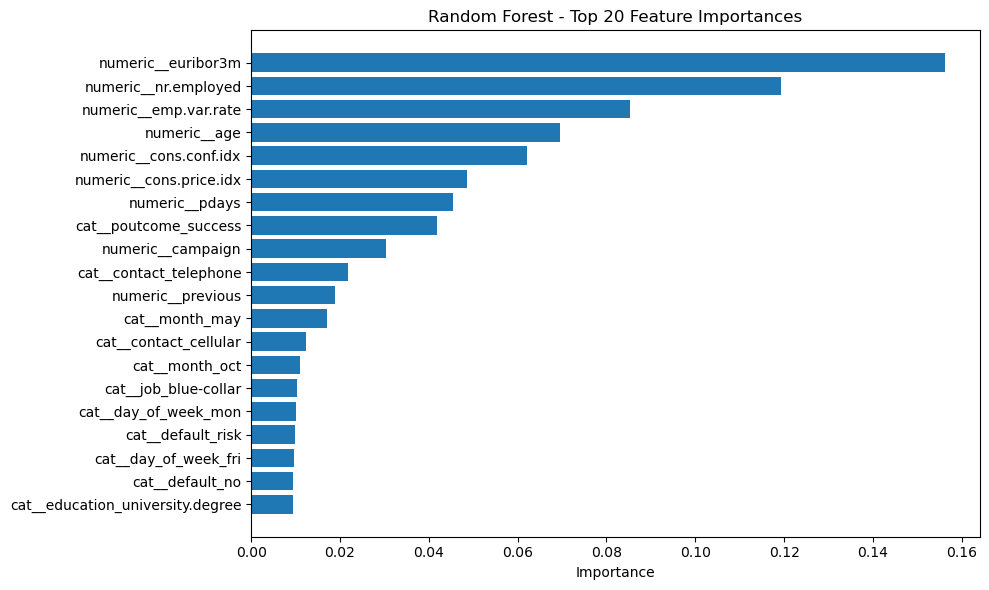

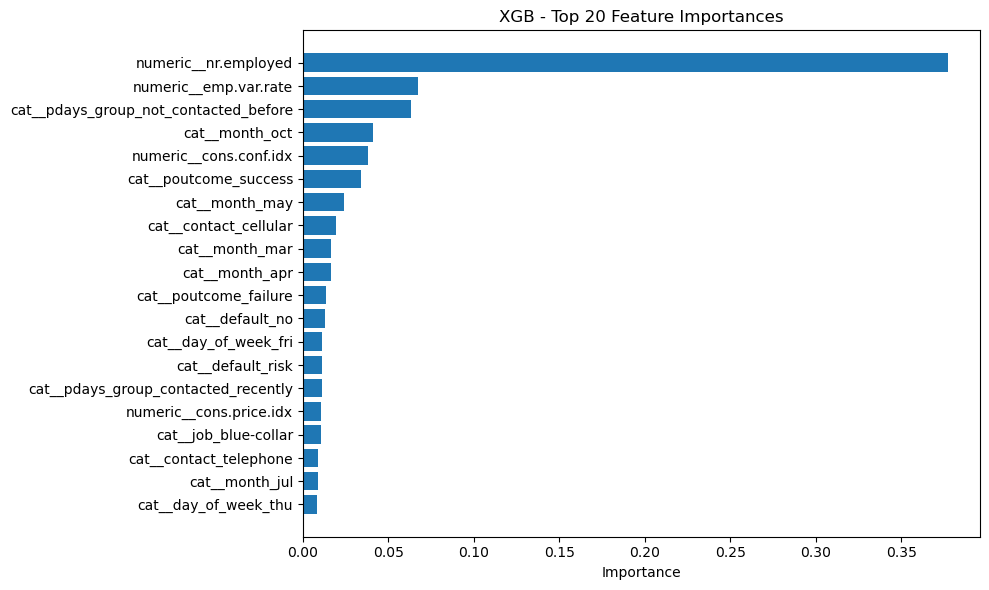

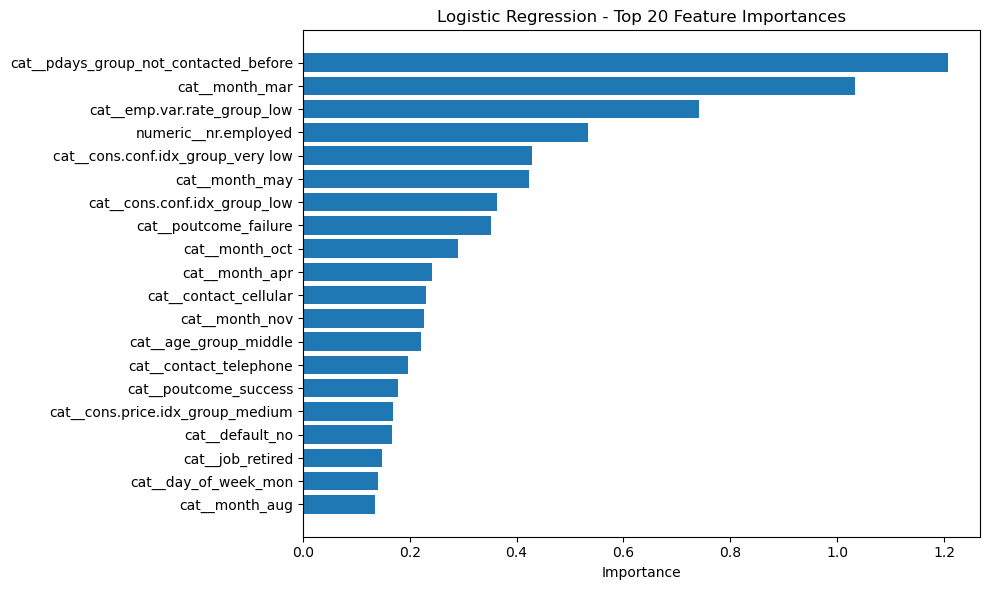

In [4]:
from src.visualizations import plot_feature_importance

plot_feature_importance(pipeline_rforest, top_n=20, name="Random Forest")
plot_feature_importance(pipeline_xgb, top_n=20, name="XGB")
plot_feature_importance(pipeline_logreg, top_n=20, name="Logistic Regression")

### Feature Importance Analysis

The feature importance results across XGBoost, Random Forest, and Logistic Regression show several consistent patterns.

**Key Predictive Drivers**  
- Macroeconomic indicators such as `nr.employed`, `emp.var.rate`, and `cons.conf.idx` are among the most influential features, highlighting the strong impact of broader economic conditions.

**Customer History and Campaign Effects**  
- Features like `pdays`, `poutcome_success`, `poutcome_failure`, and `campaign` are consistently important, indicating that prior interactions and campaign outcomes are key predictors.

**Temporal Patterns**  
- Month-related features (e.g., `month_mar`, `month_may`, `month_oct`) appear across models, suggesting seasonal effects in campaign performance.

**Contact and Demographic Features**  
- Contact type and customer attributes (e.g., job and default-related features) contribute to predictions, reflecting differences across customer segments.

**Model-Specific Observations**  
- Tree-based models capture non-linear relationships using both numerical and categorical features.  
- Logistic Regression relies more on engineered group features, reflecting linear relationships and clearer feature effects.

**Overall Insight**  
The most important signals across models come from macroeconomic context, prior campaign interactions, and temporal features, indicating that customer behavior is driven by a combination of economic conditions, engagement history, and timing rather than a single dominant factor.

### Comparison with <a href="https://github.com/Maxstef/ml-bank-additional-project/blob/main/notebooks/01_eda.ipynb">EDA Hypotheses</a>

The feature importance analysis largely confirms the hypotheses formulated during EDA, while also refining their relative importance.

**Client demographics**  
Demographic features such as age groups, job types, and default status appear in the models, but with moderate importance. This suggests they are relevant, but not the primary drivers of predictions.

**Socio-economic profile**  
Job-related features are present among important predictors, partially confirming their expected influence, though their impact is secondary compared to other feature groups.

**Financial status**  
The importance of default-related features aligns with EDA assumptions, while loan-related variables remain less influential.

**Marketing interaction history**  
Features related to previous contacts (`pdays`, `poutcome_*`) are among the most important across all models, strongly confirming that prior campaign interactions are key predictors.

**Temporal effects**  
Month-related features consistently appear among important variables, supporting the presence of seasonal patterns, while weekday effects are less pronounced than expected.

**Overall**  
The results validate the main EDA hypothesis that campaign outcomes depend on client characteristics, prior interactions, and temporal factors, while additionally highlighting the strong influence of macroeconomic indicators, which were not emphasized in the initial analysis.

## SHAP Analysis
### Data Preparation

- A single random subset of indices is sampled from the validation dataset to ensure all models are evaluated on the same observations.  
- The corresponding subset is extracted from `X_val` and `y_val` for aligned evaluation.  
- For each pipeline, the trained model is separated from preprocessing steps.  
- The subset is transformed into model-ready feature space for each pipeline and converted into DataFrames with feature names.  
- Predictions are generated for each model on the same validation subset to enable comparison.
- SHAP values are computed for each model using the corresponding transformed feature subset to explain individual predictions.

As a result, we obtain:
- trained models from each pipeline  
- a shared validation subset  
- model-specific transformed feature representations for SHAP  
- aligned predictions for consistent comparison across models  
- SHAP values for each model, enabling consistent interpretation and comparison of feature contributions across models  

In [57]:
from src.analysis.utils import get_model_and_subset, log_odds_to_proba

In [58]:
# generate indeces for forming subset
subset_indices = np.random.default_rng(4242).choice(
    X_val.index, size=200, replace=False
)

# extract models from pipelines, create pipeline specific subsets for visualizations
model_xgb, X_subset_xgb, X_full_xgb, _ = get_model_and_subset(pipeline_xgb, X_val, subset_indices=subset_indices)
model_rf, X_subset_rf, X_full_rf, _ = get_model_and_subset(pipeline_rforest, X_val, subset_indices=subset_indices)
model_lr, X_subset_lr, X_full_lr, _ = get_model_and_subset(pipeline_logreg, X_val, subset_indices=subset_indices)

# create validation data subset for analysis and comparison
X_val_subset = X_val.loc[subset_indices]
y_val_subset = y_val.loc[subset_indices]

# prediction per each pipeline for validation data subset
y_val_subset_pred_xgb = pipeline_xgb.predict(X_val_subset)
y_val_subset_pred_rf = pipeline_rforest.predict(X_val_subset)
y_val_subset_pred_lr = pipeline_logreg.predict(X_val_subset)

# xgb prediction to "yes"/"no" format for consistency
y_val_subset_pred_xgb = np.where(y_val_subset_pred_xgb == 1, "yes", "no")

In [59]:
# print accuracy to check if all good
print("XGB accuracy:", np.mean(y_val_subset_pred_xgb == y_val_subset))
print("RF accuracy:", np.mean(y_val_subset_pred_rf == y_val_subset))
print("Log Reg accuracy:", np.mean(y_val_subset_pred_lr == y_val_subset))

XGB accuracy: 0.86
RF accuracy: 0.85
Log Reg accuracy: 0.85


In [ ]:
# random forest - SHAP values
explainer_rf = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf(X_subset_rf, check_additivity=False)

In [ ]:
# XGB - SHAP values
# Use predict_proba here instead of the raw model simply because could not avoid SHAP combine with XGB error otherwise related to some model-specific internal representations
# As result - SHAP values are computed in terms of class probabilities (might be even more interpretable than log-odds)
explainer_xgb = shap.Explainer(
    model_xgb.predict_proba,
    X_subset_xgb
)

shap_values_xgb = explainer_xgb(X_subset_xgb)

In [93]:
# Log Reg - SHAP values
explainer_lr = shap.LinearExplainer(model_lr, X_subset_lr)
shap_values_lr = explainer_lr(X_subset_lr)

### SHAP - Features importance  

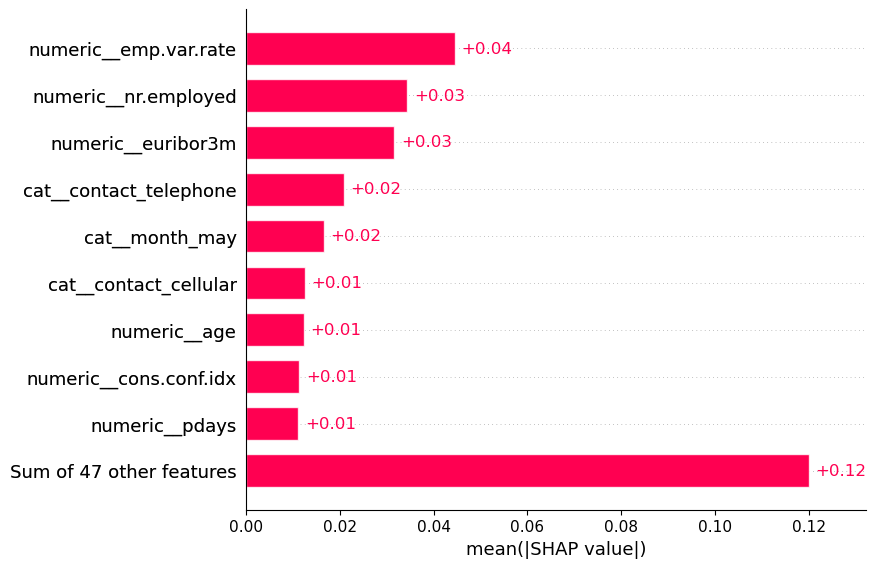

In [94]:
# Random Forest
shap.plots.bar(shap_values_rf[:, :, 1])

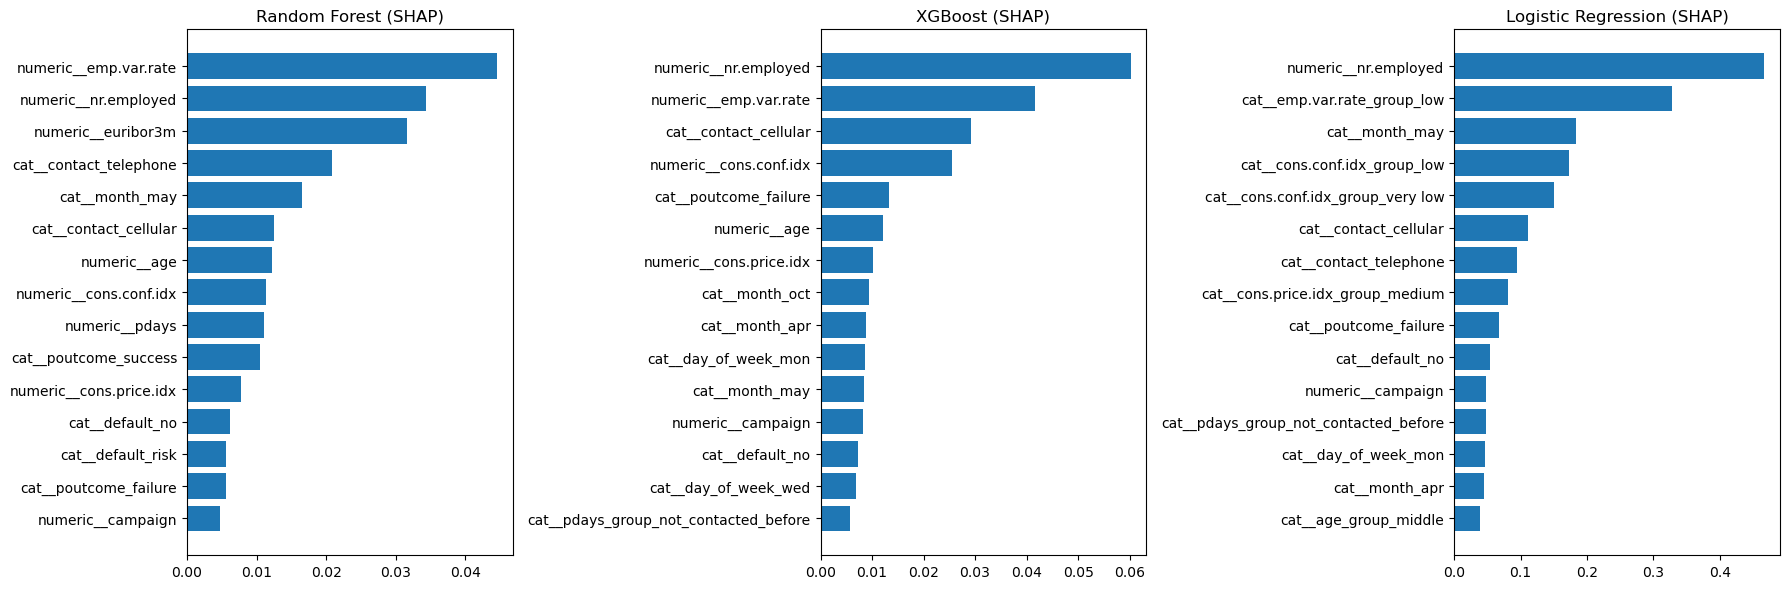

In [95]:
from src.analysis.utils import plot_shap_comparison

# compare 3 models
plot_shap_comparison(shap_values_rf, shap_values_xgb, shap_values_lr)

<span style="background-color: #4FC3F7; display:block; padding:10px">

 **SHAP - Features importance Conclusion**

 SHAP analysis shows that the most influential features across all models are macro-economic indicators (nr.employed, emp.var.rate, cons.conf.idx, cons.price.idx) and campaign-related variables (pdays, poutcome, campaign, contact type).

 Random Forest and XGBoost place strong emphasis on economic indicators, while Logistic Regression relies more on engineered categorical features such as age groups and temporal variables.

 These findings are consistent with the earlier feature importance analysis, confirming that economic conditions and prior customer interaction history are the primary drivers of the model predictions. SHAP further refines this insight by showing the directional contribution of each feature to individual predictions.

</span>

### SHAP - Summary Plot (beeswarm)

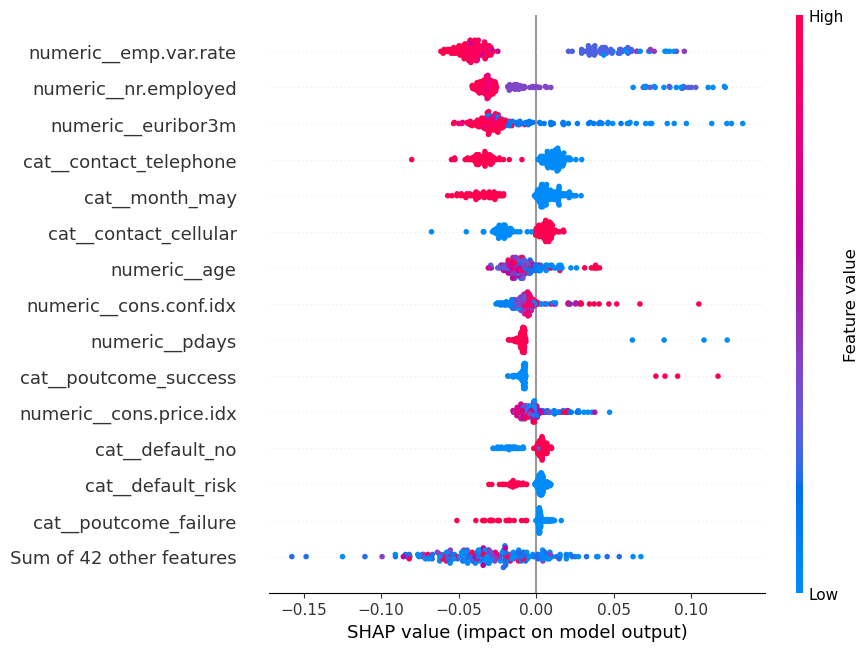

In [99]:
# Random Forest
shap.plots.beeswarm(shap_values_rf[:, :, 1], max_display=15)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Summary (Conclusion)**

- In SHAP summary (beeswarm) plots, each point represents one observation, and features are ordered by overall importance (mean absolute SHAP value).

- The color of each point represents the feature value:
  - **Red** = high feature value  
  - **Blue** = low feature value  

- The horizontal position (SHAP value) shows the impact on the model output:
  - Points to the **right (positive SHAP)** increase the probability of the target class ("yes")  
  - Points to the **left (negative SHAP)** decrease the probability of the target class  

- Economic indicators (`emp.var.rate`, `nr.employed`, `euribor3m`) are the most influential features, where higher values (red points) are generally associated with negative SHAP values, reducing the probability of subscription.

- The contact method is a strong behavioral driver: cellular contact increases the likelihood of a positive outcome, while telephone contact reduces it.

- Previous campaign outcomes (`poutcome_success`, `poutcome_failure`) and contact history (`pdays`) are highly impactful, with success strongly increasing and failure decreasing the probability of subscription.

- Credit-related features (`default_no`, `default_risk`) also contribute meaningfully, where risk status negatively affects predictions.

- Temporal and demographic features such as `cat__month_may` and `numeric__age` have weaker or more variable effects, indicating limited standalone influence compared to economic and behavioral factors.

- The feature `numeric__cons.conf.idx` shows a non-linear, context-dependent influence, suggesting interactions with other variables rather than a consistent directional effect.

</span>

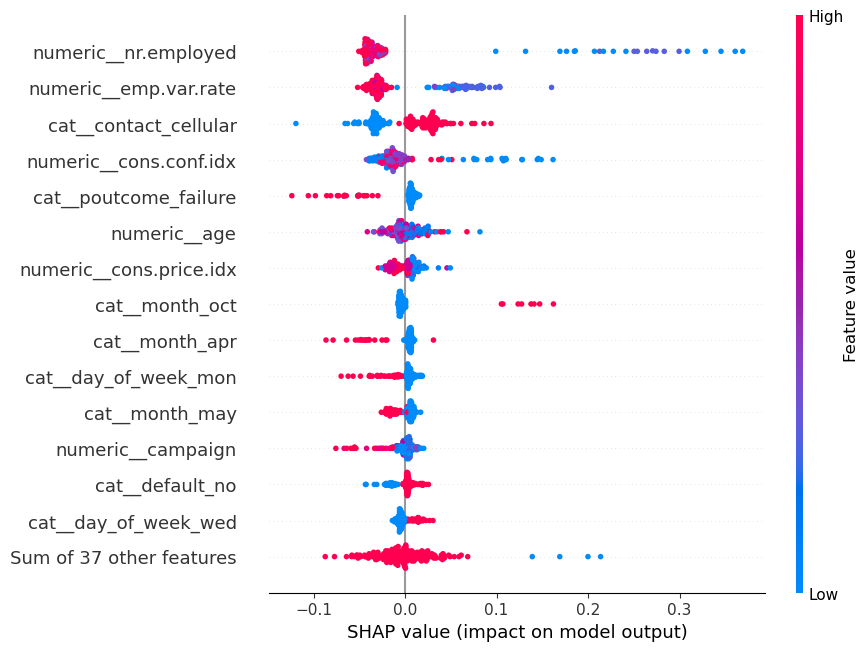

In [112]:
# XGB
shap.plots.beeswarm(shap_values_xgb[:, :, 1], max_display=15)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – XGB Summary (Conclusion)**

- Economic indicators (`emp.var.rate`, `nr.employed`) show similar directional effects as in the Random Forest model, but `nr.employed` appears to have a stronger influence in XGB, indicating that the gradient boosting model relies more heavily on employment-related signals.

- The contact method remains important: `cat__contact_cellular` has a stronger positive impact compared to Random Forest, suggesting XGB places more emphasis on communication channel effectiveness.

- Monthly features are more diversified in XGB. While `cat__month_may` still appears, additional months such as `cat__month_oct` and `cat__month_apr` are among the top features:
  - `cat__month_oct`: red values push predictions strongly to the right (positive impact)
  - `cat__month_apr`: red values push predictions to the left (negative impact)  
  This indicates XGB captures more granular temporal patterns than Random Forest.

- The feature `numeric__campaign` shows that higher values (red points) tend to decrease the probability of subscription, while lower values (blue) are closer to neutral, indicating diminishing returns with repeated contacts.

- Additional categorical features such as `cat__day_of_week_wed` and `cat__day_of_week_mon` appear among the most important features in XGB, whereas they were not prominent in the Random Forest model. This suggests XGB captures additional interaction effects related to timing.

- Features like `poutcome_failure` and `default_no` remain consistently influential across both models, confirming their robustness as predictors.

- Compared to Random Forest, XGB shows a broader spread of impactful features: several non-top features collectively contribute meaningfully, indicating that the model distributes importance more across variables rather than concentrating it in a smaller subset.

- Overall, XGB captures more nuanced and diverse patterns (especially temporal and interaction effects), while Random Forest relies more heavily on a smaller set of dominant economic and behavioral features.
</span>

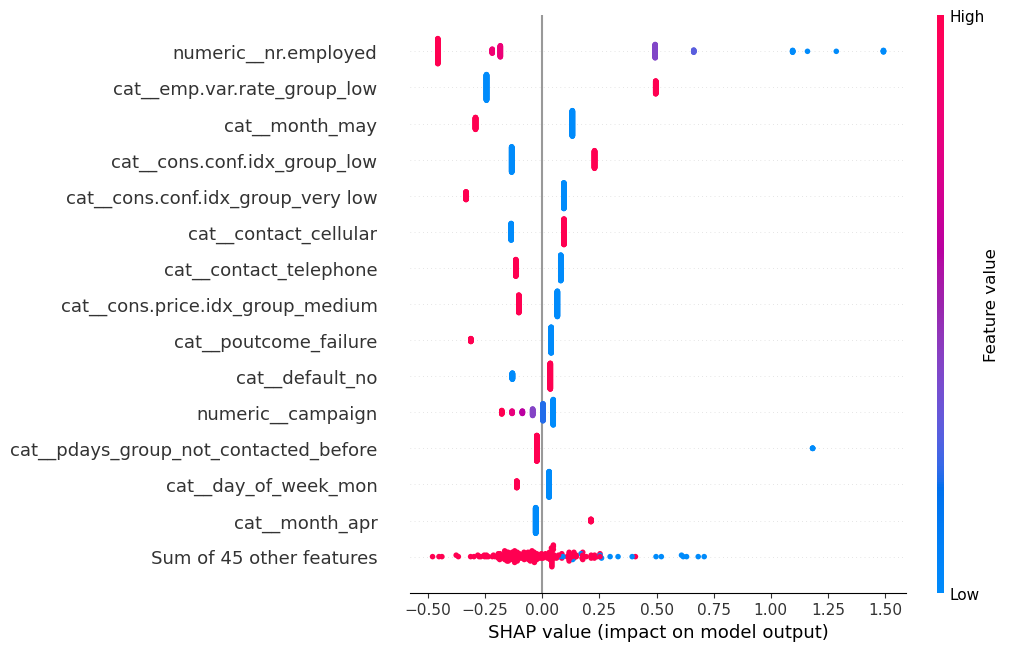

In [111]:
# Log Reg
shap.plots.beeswarm(shap_values_lr, max_display=15)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Logistic Regression Summary (Observation)**

- Most of the top features in the logistic regression model are categorical (`cat__`), which is expected due to one-hot encoding.

- In the SHAP beeswarm plot, these categorical features typically form two distinct vertical bands:
  - One group of points at **0 (blue)** representing the absence of the category  
  - One group at **1 (red)** representing the presence of the category  

- The horizontal spread of these two groups reflects the model’s learned coefficient:
  - If the red points are far to the **right**, the category strongly increases the probability of the target class ("yes")  
  - If the red points are far to the **left**, the category strongly decreases the probability  

- The distance from zero indicates the strength of the feature’s impact:
  - Features with points farther from zero have **larger absolute coefficients** and therefore stronger influence on predictions  
  - Features clustered close to zero have weaker influence  

- Compared to tree-based models (Random Forest and XGBoost), logistic regression produces more **linear and symmetric patterns**, where each feature contributes additively and independently, resulting in clearer separation between positive and negative contributions.

</span>

### SHAP - Dependence plots (scatter)

#### Tree based models

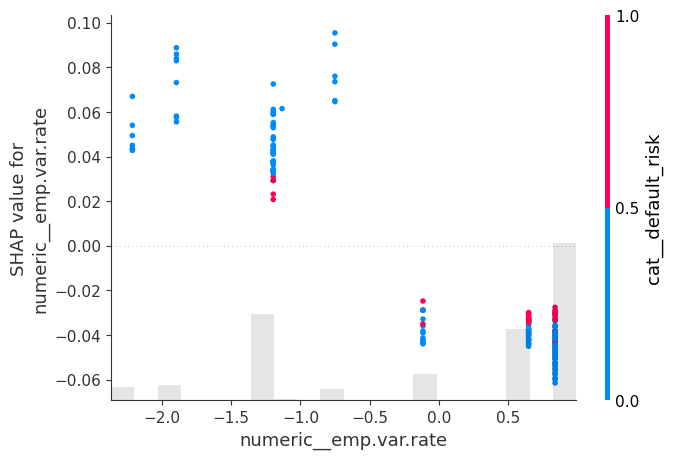

In [137]:
shap.plots.scatter(
    shap_values_rf[:, "numeric__emp.var.rate", 1],
    color=shap_values_rf[:, :, 1]
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Dependence Plot (Conclusion)**

The SHAP scatter plot for `numeric__emp.var.rate` shows a clear negative relationship with the model output: lower values contribute positively to the probability of subscription, while higher values reduce it. Additionally, coloring by `cat__default_risk` reveals an interaction effect, where higher default risk is associated with more negative SHAP values at higher employment variation rates. This suggests that unfavorable economic conditions combined with higher credit risk reinforce the model’s tendency to predict a lower likelihood of subscription.

</span>

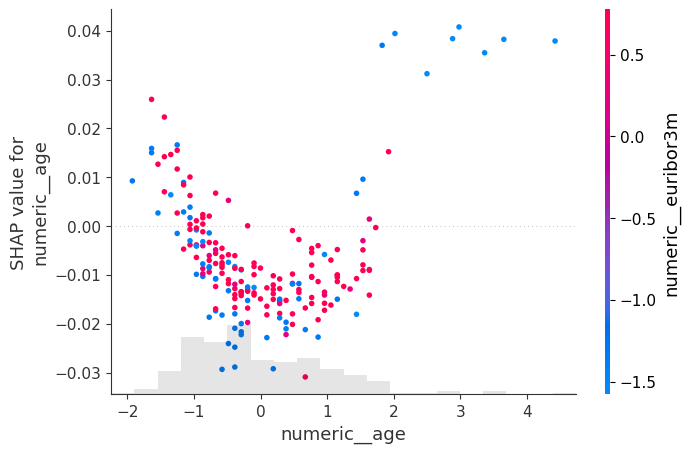

In [126]:
shap.plots.scatter(
    shap_values_rf[:, "numeric__age", 1],
    color=shap_values_rf[:, :, 1]
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Dependence Plot (Conclusion)**

The SHAP scatter plot for `numeric__age` shows a non-linear relationship with the model output. Very low and very high age values tend to have a positive impact on the probability of subscription, while medium age values generally have a slightly negative impact. This suggests a U-shaped effect of age on predictions.

When coloring by `numeric__euribor3m`, no strong interaction pattern is observed, indicating that interest rates do not significantly modify the effect of age. The feature `age` therefore appears to act mostly independently, with limited interaction effects and a relatively weaker overall influence compared to more dominant economic and behavioral features.

</span>

#### Logistic Regression

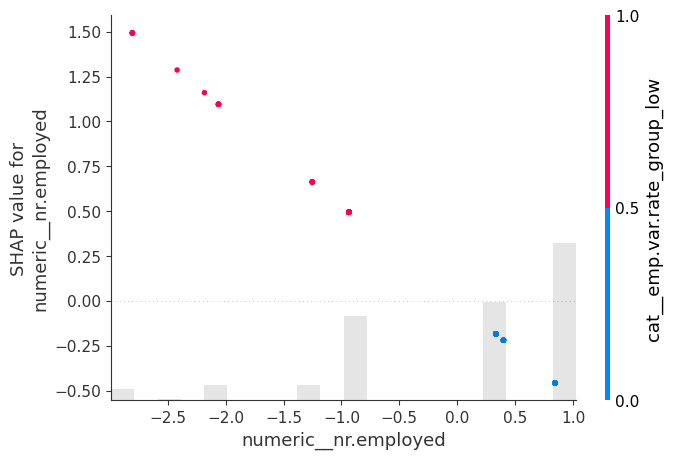

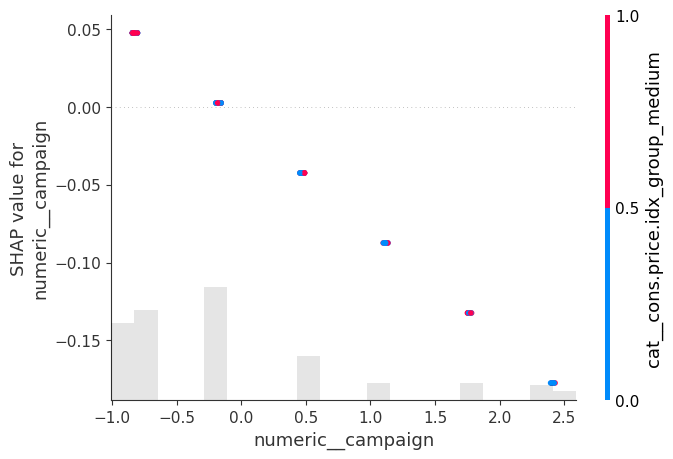

In [138]:
# two most important among numeric features of logisting regression
shap.plots.scatter(
    shap_values_lr[:, "numeric__nr.employed"],
    color=shap_values_lr[:, "cat__emp.var.rate_group_low"]
)

shap.plots.scatter(
    shap_values_lr[:, "numeric__campaign"],
    color=shap_values_lr[:, :]
)

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Logistic Regression Dependence Plots (Conclusion)**

The scatter plots for logistic regression show a clear linear relationship between feature values and their SHAP contributions. For `numeric__nr.employed`, higher values consistently lead to negative SHAP values, while lower values contribute positively. Coloring by `cat__emp.var.rate_group_low` reveals a strong alignment between the two features, suggesting correlation rather than interaction.

For `numeric__campaign`, a similar linear negative relationship is observed, where higher values reduce the probability of subscription. When colored by `cat__cons.price.idx_group_medium`, no strong separation is visible, indicating weak or no interaction between these features. Overall, the patterns reflect the linear nature of logistic regression, where features contribute additively and interactions are limited.

</span>

### SHAP - Heatmap

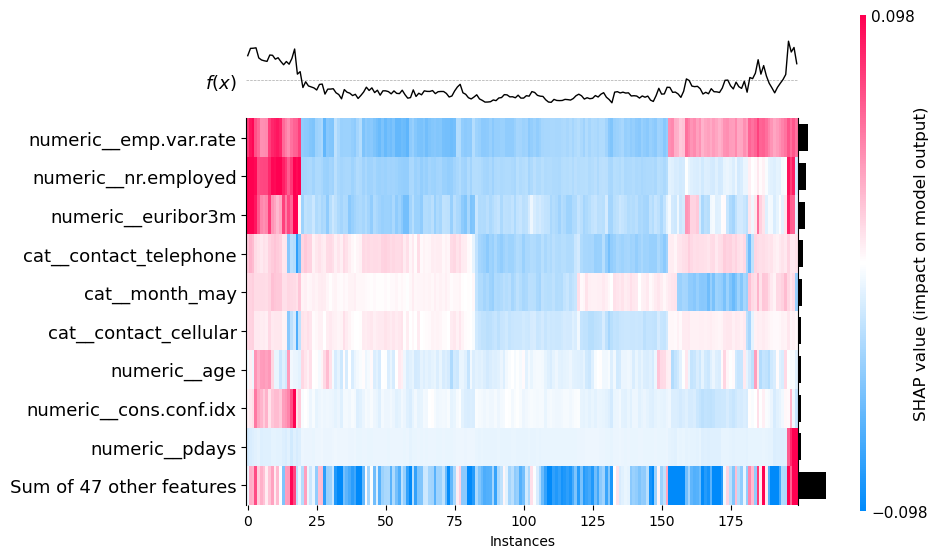

In [139]:
shap.plots.heatmap(shap_values_rf[:, :, 1]);

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Random Forest Heatmap (Conclusion)**

The SHAP heatmap for the Random Forest model shows that the most important features have the largest variation in SHAP values across samples. For these features, extreme values (low and high) tend to produce positive SHAP values (red), while mid-range values are more often associated with negative contributions (blue), indicating non-linear, threshold-like effects. The strongest features exhibit the clearest color gradients, confirming their higher influence on the model’s predictions.

</span>

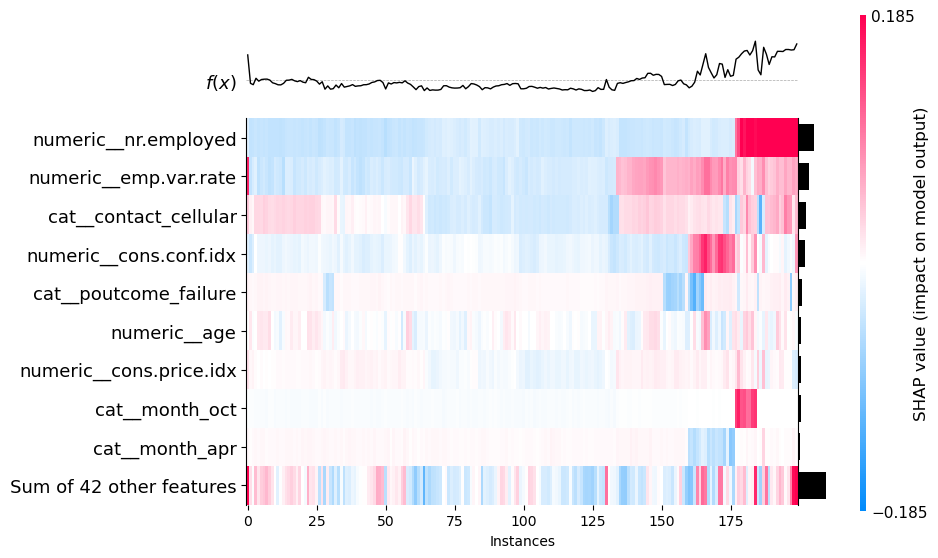

In [140]:
shap.plots.heatmap(shap_values_xgb[:, :, 1]);

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – XGB Heatmap (Conclusion)**

The SHAP heatmap for the XGBoost model shows that the top features have strong, asymmetric effects, with predominantly positive (red) contributions on the right and little or no positive contribution on the left. This indicates that higher feature values strongly increase the probability of subscription, while lower values have weaker or negative effects. Lower-ranked features show more evenly distributed SHAP values, suggesting more moderate and less dominant influence. Overall, XGBoost relies heavily on a few key features with strong directional impact.

</span>

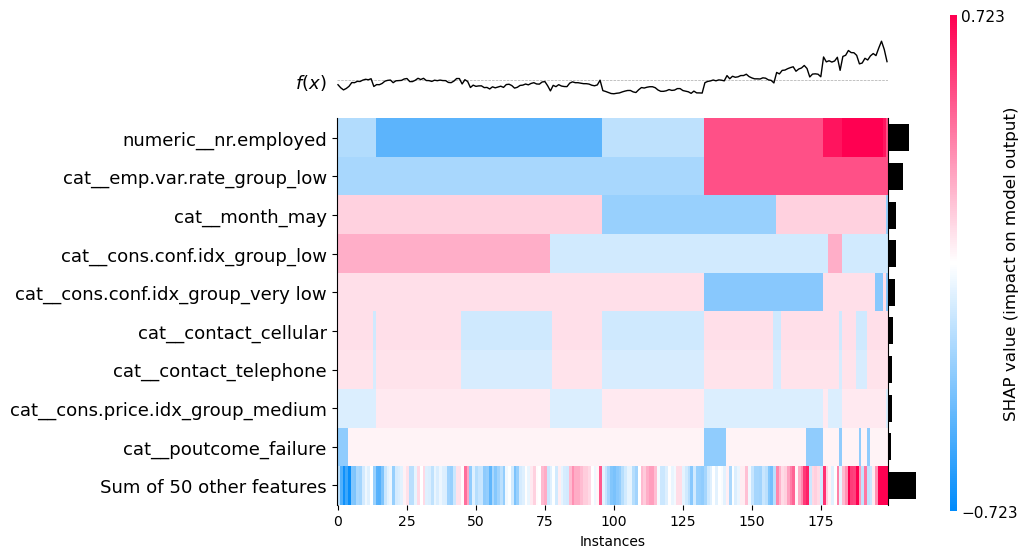

In [141]:
shap.plots.heatmap(shap_values_lr[:, :]);

<span style="background-color: #4FC3F7; display:block; padding:10px">

**SHAP – Lgistic Regression Heatmap (Conclusion)**

The SHAP heatmap for logistic regression shows that the top features have a clear directional effect, with higher values increasing predictions (red on the right) and lower values decreasing them (blue on the left). The remaining features are more evenly distributed, indicating weaker and more uniform influence. Overall, the model is driven mainly by a few dominant linear features.

</span>